In [1]:
import sounddevice as sd
import numpy as np
import soundfile as sf
from src.audio_device import AudioDevice
from src.sharc import Sharc
import matplotlib.pyplot as plt
import librosa
import mido


In [2]:
print(sd.query_devices())

   0 Microsoft Sound Mapper - Input, MME (2 in, 0 out)
>  1 Analogue 1 + 2 (8- Focusrite US, MME (8 in, 0 out)
   2 Microphone Array (Intel® Smart , MME (4 in, 0 out)
   3 Microsoft Sound Mapper - Output, MME (0 in, 2 out)
<  4 Realtek HD Audio 2nd output (Re, MME (0 in, 2 out)
   5 Speakers (8- Focusrite USB Audi, MME (0 in, 8 out)
   6 Speakers (Realtek(R) Audio), MME (0 in, 2 out)
   7 Primary Sound Capture Driver, Windows DirectSound (2 in, 0 out)
   8 Analogue 1 + 2 (8- Focusrite USB Audio), Windows DirectSound (8 in, 0 out)
   9 Microphone Array (Intel® Smart Sound Technology (Intel® SST)), Windows DirectSound (4 in, 0 out)
  10 Primary Sound Driver, Windows DirectSound (0 in, 2 out)
  11 Realtek HD Audio 2nd output (Realtek(R) Audio), Windows DirectSound (0 in, 2 out)
  12 Speakers (8- Focusrite USB Audio), Windows DirectSound (0 in, 8 out)
  13 Speakers (Realtek(R) Audio), Windows DirectSound (0 in, 2 out)
  14 Speakers (8- Focusrite USB Audio), Windows WASAPI (0 in, 2 out)
  1

In [3]:
arthur, sr = sf.read('data/arthur_clip_48k.wav')

fs = 96_000
arthur_96 = librosa.resample(arthur, orig_sr=sr, target_sr=fs)


ad = AudioDevice(fs, in_device=1, out_device=4)

In [ ]:
sharc = Sharc(arthur_96, ad)


Using output: USB2.0-MIDI 2
Using input:  USB2.0-MIDI 1


In [7]:
sharc.no_cancel(n_repeats=1)

In [6]:
sharc.no_cancel(n_repeats=1)
sharc.no_cancel(n_repeats=2)
sharc.no_cancel(n_repeats=5)

Overall ANC / No ANC: -0.04 dB


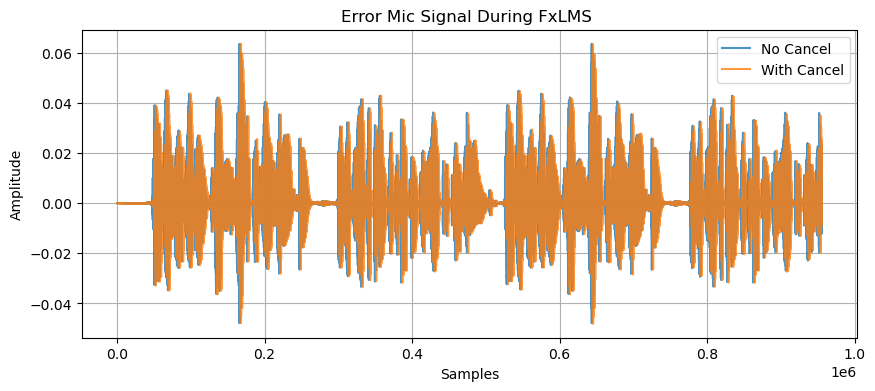

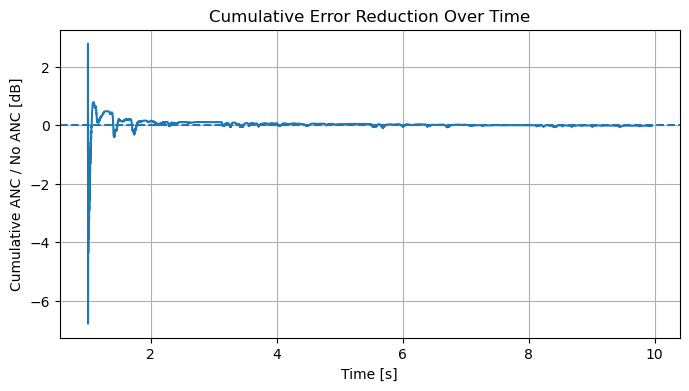

In [9]:
sharc.cancel(n_repeats=2)
sharc.plot_error_mic()
sharc.plot_cumulative_error_reduction()

In [15]:
sharc.no_cancel(2)

In [10]:
sharc.set_mu(1.6e-3)
sharc.set_cancel_gain(0.05)
sharc.reset()
sharc.cancel(2)

Overall ANC / No ANC: -1.04 dB


np.float32(-1.041506)

In [8]:
test_params = [
    {"mu": 7e-4,  "cancel_gain": 0.06},
    {"mu": 1e-3,  "cancel_gain": 0.05},
    {"mu": 1.3e-3,"cancel_gain": 0.025},
    {"mu": 1.6e-3,"cancel_gain": 0.025},
]

for t in test_params:
    sharc.set_mu(t['mu'])
    sharc.set_cancel_gain(t['cancel_gain'])
    sharc.reset()
    print(t)
    sharc.cancel(2)
    print()

{'mu': 0.0007, 'cancel_gain': 0.06}
Overall ANC / No ANC: -0.63 dB

{'mu': 0.001, 'cancel_gain': 0.05}
Overall ANC / No ANC: -0.76 dB

{'mu': 0.0013, 'cancel_gain': 0.025}
Overall ANC / No ANC: -0.57 dB

{'mu': 0.0016, 'cancel_gain': 0.025}
Overall ANC / No ANC: -0.62 dB



In [10]:
param_dict = {
    "mu": [5e-4, 7e-4, 1e-3, 1.3e-3, 1.6e-3, 2e-3],
    "cancel_gain": [0.025, 0.04, 0.05, 0.06, 0.075],
    "leak": [3e-7, 1e-7],
    "lag": 86
}
sharc.grid_search(n_repeats=2, param_dict=param_dict)

Params: {'mu': 0.0005, 'cancel_gain': 0.025, 'leak': 3e-07, 'lag': 86}
Overall ANC / No ANC: -0.34 dB

Params: {'mu': 0.0005, 'cancel_gain': 0.025, 'leak': 1e-07, 'lag': 86}
Overall ANC / No ANC: -0.27 dB

Params: {'mu': 0.0005, 'cancel_gain': 0.04, 'leak': 3e-07, 'lag': 86}
Overall ANC / No ANC: -0.41 dB

Params: {'mu': 0.0005, 'cancel_gain': 0.04, 'leak': 1e-07, 'lag': 86}
Overall ANC / No ANC: -0.41 dB

Params: {'mu': 0.0005, 'cancel_gain': 0.05, 'leak': 3e-07, 'lag': 86}
Overall ANC / No ANC: -0.52 dB

Params: {'mu': 0.0005, 'cancel_gain': 0.05, 'leak': 1e-07, 'lag': 86}
Overall ANC / No ANC: -0.52 dB

Params: {'mu': 0.0005, 'cancel_gain': 0.06, 'leak': 3e-07, 'lag': 86}
Overall ANC / No ANC: -0.59 dB

Params: {'mu': 0.0005, 'cancel_gain': 0.06, 'leak': 1e-07, 'lag': 86}
Overall ANC / No ANC: -0.57 dB

Params: {'mu': 0.0005, 'cancel_gain': 0.075, 'leak': 3e-07, 'lag': 86}
Overall ANC / No ANC: -0.66 dB

Params: {'mu': 0.0005, 'cancel_gain': 0.075, 'leak': 1e-07, 'lag': 86}
Overall 

({'mu': 0.002, 'cancel_gain': 0.075, 'leak': 1e-07, 'lag': 86},
 np.float32(-1.7825216))

In [11]:
param_dict = {
    "mu": 2e-3,
    "cancel_gain": 0.075,
    "leak": 1e-7,
    "lag": list(range(60, 100, 2))
}
for i in range(3):
    sharc.grid_search(n_repeats=2, param_dict=param_dict)

Params: {'mu': 0.002, 'cancel_gain': 0.075, 'leak': 1e-07, 'lag': 60}
Overall ANC / No ANC: -1.35 dB

Params: {'mu': 0.002, 'cancel_gain': 0.075, 'leak': 1e-07, 'lag': 62}
Overall ANC / No ANC: -1.34 dB

Params: {'mu': 0.002, 'cancel_gain': 0.075, 'leak': 1e-07, 'lag': 64}
Overall ANC / No ANC: -1.30 dB

Params: {'mu': 0.002, 'cancel_gain': 0.075, 'leak': 1e-07, 'lag': 66}
Overall ANC / No ANC: -1.52 dB

Params: {'mu': 0.002, 'cancel_gain': 0.075, 'leak': 1e-07, 'lag': 68}
Overall ANC / No ANC: -1.56 dB

Params: {'mu': 0.002, 'cancel_gain': 0.075, 'leak': 1e-07, 'lag': 70}
Overall ANC / No ANC: -1.53 dB

Params: {'mu': 0.002, 'cancel_gain': 0.075, 'leak': 1e-07, 'lag': 72}
Overall ANC / No ANC: -1.50 dB

Params: {'mu': 0.002, 'cancel_gain': 0.075, 'leak': 1e-07, 'lag': 74}
Overall ANC / No ANC: -1.69 dB

Params: {'mu': 0.002, 'cancel_gain': 0.075, 'leak': 1e-07, 'lag': 76}
Overall ANC / No ANC: -1.65 dB

Params: {'mu': 0.002, 'cancel_gain': 0.075, 'leak': 1e-07, 'lag': 78}
Overall ANC 

In [12]:
param_dict = {
    "mu": [0.0015, 0.0020, 0.0025, 0.0030, 0.0035, 0.0040],
    "cancel_gain": [0.06, 0.075, 0.09, 0.105, 0.12],
    "leak": 1e-7,
    "lag": 86
}
sharc.grid_search(n_repeats=2, param_dict=param_dict)

Params: {'mu': 0.0015, 'cancel_gain': 0.06, 'leak': 1e-07, 'lag': 86}
Overall ANC / No ANC: -1.31 dB

Params: {'mu': 0.0015, 'cancel_gain': 0.075, 'leak': 1e-07, 'lag': 86}
Overall ANC / No ANC: -1.44 dB

Params: {'mu': 0.0015, 'cancel_gain': 0.09, 'leak': 1e-07, 'lag': 86}
Overall ANC / No ANC: -1.59 dB

Params: {'mu': 0.0015, 'cancel_gain': 0.105, 'leak': 1e-07, 'lag': 86}
Overall ANC / No ANC: -1.85 dB

Params: {'mu': 0.0015, 'cancel_gain': 0.12, 'leak': 1e-07, 'lag': 86}
Overall ANC / No ANC: -1.72 dB

Params: {'mu': 0.002, 'cancel_gain': 0.06, 'leak': 1e-07, 'lag': 86}
Overall ANC / No ANC: -1.48 dB

Params: {'mu': 0.002, 'cancel_gain': 0.075, 'leak': 1e-07, 'lag': 86}
Overall ANC / No ANC: -1.81 dB

Params: {'mu': 0.002, 'cancel_gain': 0.09, 'leak': 1e-07, 'lag': 86}
Overall ANC / No ANC: -1.76 dB

Params: {'mu': 0.002, 'cancel_gain': 0.105, 'leak': 1e-07, 'lag': 86}
Overall ANC / No ANC: -1.85 dB

Params: {'mu': 0.002, 'cancel_gain': 0.12, 'leak': 1e-07, 'lag': 86}
Overall ANC /

({'mu': 0.0035, 'cancel_gain': 0.105, 'leak': 1e-07, 'lag': 86},
 np.float32(-2.4008832))

In [13]:
param_dict = {
    "mu": [0.0030, .00325, 0.0035, 0.00375],
    "cancel_gain": [0.09, .1, 0.105, 0.11],
    "leak": 1e-7,
    "lag": 86
}
for i in range(3):
    sharc.grid_search(n_repeats=2, param_dict=param_dict)

Params: {'mu': 0.003, 'cancel_gain': 0.09, 'leak': 1e-07, 'lag': 86}
Overall ANC / No ANC: -2.09 dB

Params: {'mu': 0.003, 'cancel_gain': 0.1, 'leak': 1e-07, 'lag': 86}
Overall ANC / No ANC: -1.89 dB

Params: {'mu': 0.003, 'cancel_gain': 0.105, 'leak': 1e-07, 'lag': 86}
Overall ANC / No ANC: -1.43 dB

Params: {'mu': 0.003, 'cancel_gain': 0.11, 'leak': 1e-07, 'lag': 86}
Overall ANC / No ANC: -2.37 dB

Params: {'mu': 0.00325, 'cancel_gain': 0.09, 'leak': 1e-07, 'lag': 86}
Overall ANC / No ANC: -1.79 dB

Params: {'mu': 0.00325, 'cancel_gain': 0.1, 'leak': 1e-07, 'lag': 86}
Overall ANC / No ANC: -1.68 dB

Params: {'mu': 0.00325, 'cancel_gain': 0.105, 'leak': 1e-07, 'lag': 86}
Overall ANC / No ANC: -2.13 dB

Params: {'mu': 0.00325, 'cancel_gain': 0.11, 'leak': 1e-07, 'lag': 86}
Overall ANC / No ANC: -1.12 dB

Params: {'mu': 0.0035, 'cancel_gain': 0.09, 'leak': 1e-07, 'lag': 86}
Overall ANC / No ANC: -0.73 dB

Params: {'mu': 0.0035, 'cancel_gain': 0.1, 'leak': 1e-07, 'lag': 86}
Overall ANC /

In [14]:
param_dict = {
    "mu": [0.0030, .00325, 0.0035, 0.00375],
    "cancel_gain": [0.09, .1, 0.105, 0.11],
    "leak": 3e-7,
    "lag": 86
}
for i in range(3):
    sharc.grid_search(n_repeats=2, param_dict=param_dict)

Params: {'mu': 0.003, 'cancel_gain': 0.09, 'leak': 3e-07, 'lag': 86}
Overall ANC / No ANC: -2.41 dB

Params: {'mu': 0.003, 'cancel_gain': 0.1, 'leak': 3e-07, 'lag': 86}
Overall ANC / No ANC: -2.29 dB

Params: {'mu': 0.003, 'cancel_gain': 0.105, 'leak': 3e-07, 'lag': 86}
Overall ANC / No ANC: -2.11 dB

Params: {'mu': 0.003, 'cancel_gain': 0.11, 'leak': 3e-07, 'lag': 86}
Overall ANC / No ANC: -1.33 dB

Params: {'mu': 0.00325, 'cancel_gain': 0.09, 'leak': 3e-07, 'lag': 86}
Overall ANC / No ANC: -1.39 dB

Params: {'mu': 0.00325, 'cancel_gain': 0.1, 'leak': 3e-07, 'lag': 86}
Overall ANC / No ANC: -2.20 dB

Params: {'mu': 0.00325, 'cancel_gain': 0.105, 'leak': 3e-07, 'lag': 86}
Overall ANC / No ANC: -0.81 dB

Params: {'mu': 0.00325, 'cancel_gain': 0.11, 'leak': 3e-07, 'lag': 86}
Overall ANC / No ANC: -1.65 dB

Params: {'mu': 0.0035, 'cancel_gain': 0.09, 'leak': 3e-07, 'lag': 86}
Overall ANC / No ANC: -2.10 dB

Params: {'mu': 0.0035, 'cancel_gain': 0.1, 'leak': 3e-07, 'lag': 86}
Overall ANC /

In [15]:
param_dict = {
    "mu": [0.0030, .00325, 0.0035, 0.00375],
    "cancel_gain": [0.09, .1, 0.105, 0.11],
    "leak": 1e-6,
    "lag": 86
}
for i in range(3):
    sharc.grid_search(n_repeats=2, param_dict=param_dict)

Params: {'mu': 0.003, 'cancel_gain': 0.09, 'leak': 1e-06, 'lag': 86}
Overall ANC / No ANC: -2.33 dB

Params: {'mu': 0.003, 'cancel_gain': 0.1, 'leak': 1e-06, 'lag': 86}
Overall ANC / No ANC: -1.70 dB

Params: {'mu': 0.003, 'cancel_gain': 0.105, 'leak': 1e-06, 'lag': 86}
Overall ANC / No ANC: -1.80 dB

Params: {'mu': 0.003, 'cancel_gain': 0.11, 'leak': 1e-06, 'lag': 86}
Overall ANC / No ANC: -2.39 dB

Params: {'mu': 0.00325, 'cancel_gain': 0.09, 'leak': 1e-06, 'lag': 86}
Overall ANC / No ANC: -2.26 dB

Params: {'mu': 0.00325, 'cancel_gain': 0.1, 'leak': 1e-06, 'lag': 86}
Overall ANC / No ANC: -1.42 dB

Params: {'mu': 0.00325, 'cancel_gain': 0.105, 'leak': 1e-06, 'lag': 86}
Overall ANC / No ANC: -1.80 dB

Params: {'mu': 0.00325, 'cancel_gain': 0.11, 'leak': 1e-06, 'lag': 86}
Overall ANC / No ANC: -2.03 dB

Params: {'mu': 0.0035, 'cancel_gain': 0.09, 'leak': 1e-06, 'lag': 86}
Overall ANC / No ANC: -1.31 dB

Params: {'mu': 0.0035, 'cancel_gain': 0.1, 'leak': 1e-06, 'lag': 86}
Overall ANC /

In [17]:
param_dict = {
    "mu": [0.003, 0.00325, 0.0035],
    "cancel_gain": [0.09, 0.10, 0.11],
    "leak": 3e-6,
    "lag": 86
}
for i in range(3):
    sharc.grid_search(n_repeats=2, param_dict=param_dict)

Params: {'mu': 0.003, 'cancel_gain': 0.09, 'leak': 3e-06, 'lag': 86}
Overall ANC / No ANC: -2.15 dB

Params: {'mu': 0.003, 'cancel_gain': 0.1, 'leak': 3e-06, 'lag': 86}
Overall ANC / No ANC: -1.98 dB

Params: {'mu': 0.003, 'cancel_gain': 0.11, 'leak': 3e-06, 'lag': 86}
Overall ANC / No ANC: -2.00 dB

Params: {'mu': 0.00325, 'cancel_gain': 0.09, 'leak': 3e-06, 'lag': 86}
Overall ANC / No ANC: -1.42 dB

Params: {'mu': 0.00325, 'cancel_gain': 0.1, 'leak': 3e-06, 'lag': 86}
Overall ANC / No ANC: -2.21 dB

Params: {'mu': 0.00325, 'cancel_gain': 0.11, 'leak': 3e-06, 'lag': 86}
Overall ANC / No ANC: -2.34 dB

Params: {'mu': 0.0035, 'cancel_gain': 0.09, 'leak': 3e-06, 'lag': 86}
Overall ANC / No ANC: -2.12 dB

Params: {'mu': 0.0035, 'cancel_gain': 0.1, 'leak': 3e-06, 'lag': 86}
Overall ANC / No ANC: -2.18 dB

Params: {'mu': 0.0035, 'cancel_gain': 0.11, 'leak': 3e-06, 'lag': 86}
Overall ANC / No ANC: -1.14 dB

Best Params: {'mu': 0.00325, 'cancel_gain': 0.11, 'leak': 3e-06, 'lag': 86}, Best ANC

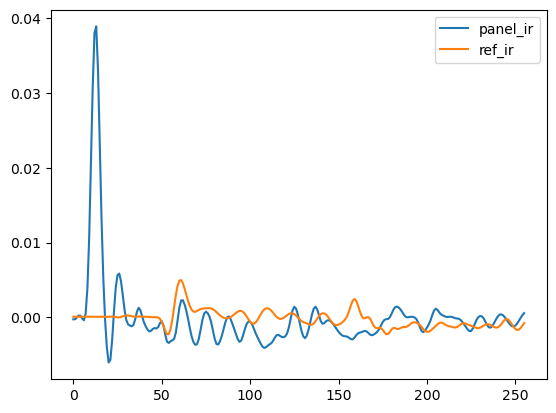

In [11]:
sharc.prep_irs(ir_len=256, panel_to_err_cm=4.5)

In [11]:
param_dict = {
    "mu": [0.003, 0.00325, 0.0035],
    "cancel_gain": [0.09, 0.10, 0.11],
    "leak": 1e-6,
    "lag": 86
}
sharc.grid_search(n_repeats=5, param_dict=param_dict)

Params: {'mu': 0.003, 'cancel_gain': 0.09, 'leak': 1e-06, 'lag': 86}
Overall ANC / No ANC: -2.44 dB

Params: {'mu': 0.003, 'cancel_gain': 0.1, 'leak': 1e-06, 'lag': 86}
Overall ANC / No ANC: -2.84 dB

Params: {'mu': 0.003, 'cancel_gain': 0.11, 'leak': 1e-06, 'lag': 86}
Overall ANC / No ANC: -2.92 dB

Params: {'mu': 0.00325, 'cancel_gain': 0.09, 'leak': 1e-06, 'lag': 86}
Overall ANC / No ANC: -2.75 dB

Params: {'mu': 0.00325, 'cancel_gain': 0.1, 'leak': 1e-06, 'lag': 86}
Overall ANC / No ANC: -2.66 dB

Params: {'mu': 0.00325, 'cancel_gain': 0.11, 'leak': 1e-06, 'lag': 86}
Overall ANC / No ANC: -3.01 dB

Params: {'mu': 0.0035, 'cancel_gain': 0.09, 'leak': 1e-06, 'lag': 86}
Overall ANC / No ANC: -2.60 dB

Params: {'mu': 0.0035, 'cancel_gain': 0.1, 'leak': 1e-06, 'lag': 86}
Overall ANC / No ANC: -2.91 dB

Params: {'mu': 0.0035, 'cancel_gain': 0.11, 'leak': 1e-06, 'lag': 86}
Overall ANC / No ANC: -2.96 dB

Best Params: {'mu': 0.00325, 'cancel_gain': 0.11, 'leak': 1e-06, 'lag': 86}, Best ANC

({'mu': 0.00325, 'cancel_gain': 0.11, 'leak': 1e-06, 'lag': 86},
 np.float32(-3.0130682))

In [12]:
sharc.no_cancel(10)
sharc.no_cancel(20)

Overall ANC / No ANC: -3.07 dB


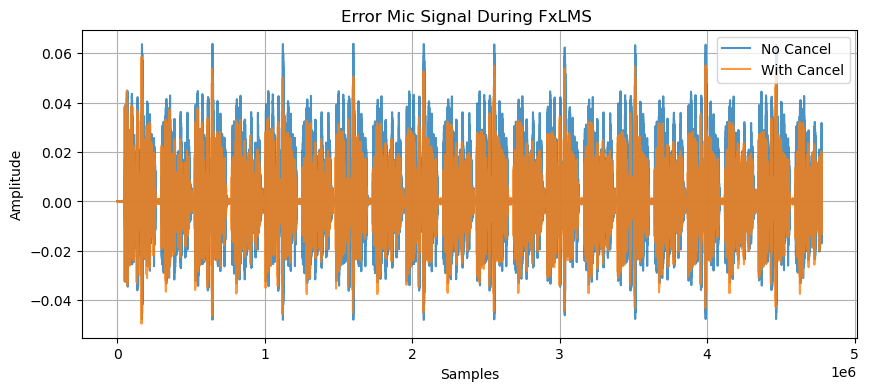

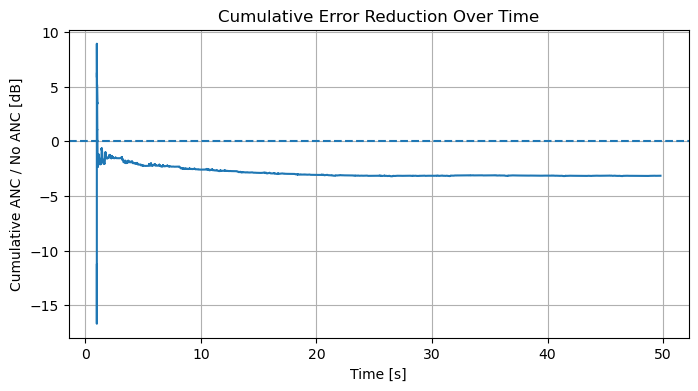

In [17]:
sharc.set_mu(0.00325)
sharc.set_cancel_gain(0.11)
sharc.reset()
sharc.cancel(10)
sharc.plot_error_mic()
sharc.plot_cumulative_error_reduction()

Overall ANC / No ANC: -2.29 dB


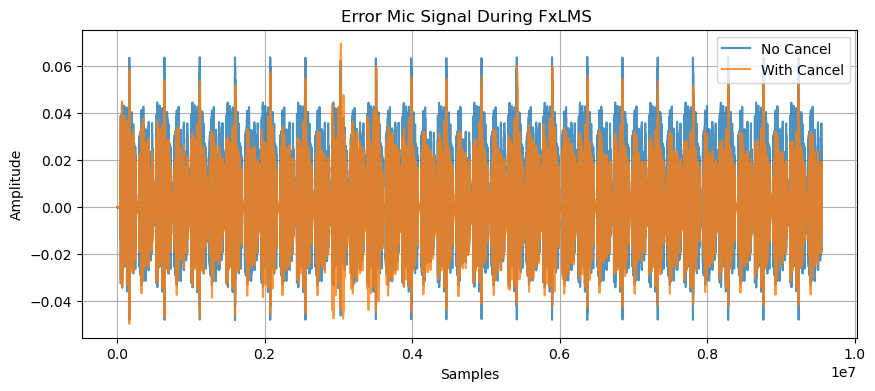

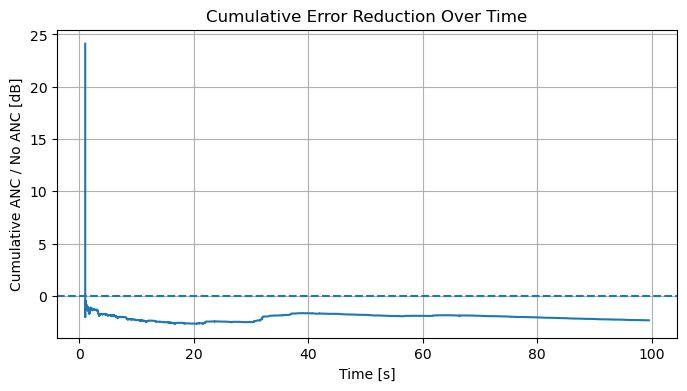

In [18]:
sharc.set_mu(0.003)
sharc.set_cancel_gain(0.11)
sharc.reset()
sharc.cancel(20)
sharc.plot_error_mic()
sharc.plot_cumulative_error_reduction()

Overall ANC / No ANC: -3.22 dB


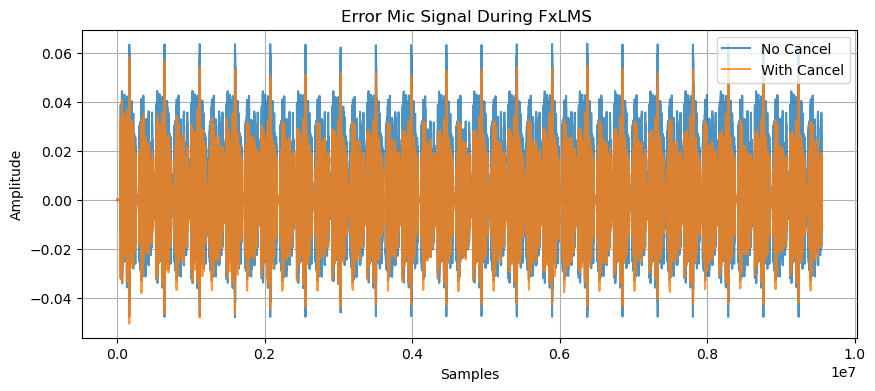

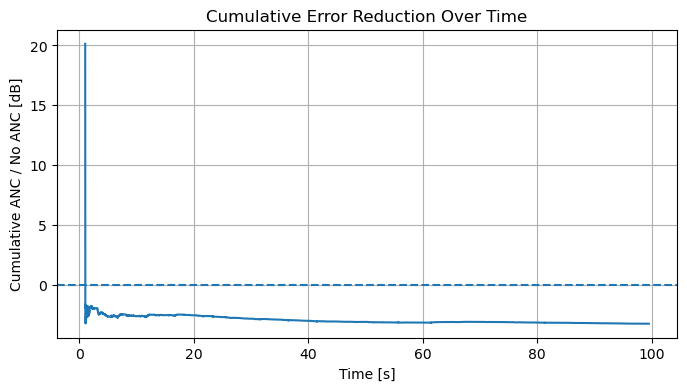

In [ ]:
sharc.set_mu(0.003)
sharc.set_cancel_gain(0.11)
sharc.reset()
sharc.seed_delta(24)
sharc.cancel(20)
sharc.plot_error_mic()
sharc.plot_cumulative_error_reduction()

No baseline recording found for n_repeats=20.


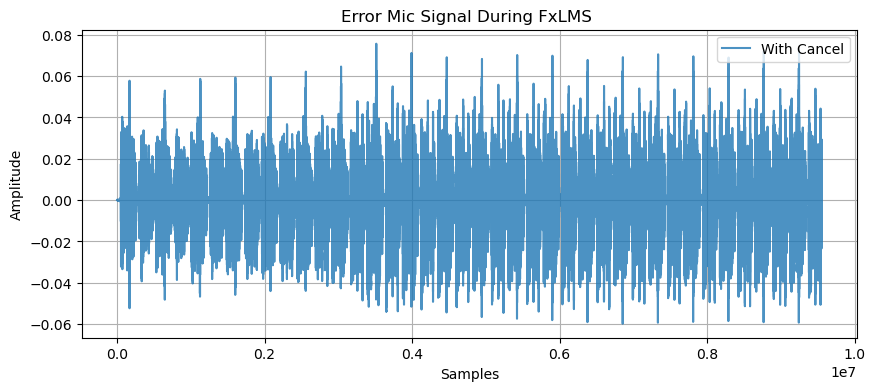

TypeError: object of type 'NoneType' has no len()

In [8]:
sharc.set_mu(0.00325)
sharc.set_cancel_gain(0.11)
sharc.reset()
sharc.seed_delta(16)
sharc.cancel(20)
sharc.plot_error_mic()
sharc.plot_cumulative_error_reduction()

In [7]:
for i in range(0, 1024, 8):
    sharc.reset()
    sharc.set_adapt(False)
    sharc.seed_delta(i)
    print("index", i)
    sharc.cancel(1)
    print()

index 0
Overall ANC / No ANC: -0.36 dB

index 8
Overall ANC / No ANC: -0.37 dB

index 16
Overall ANC / No ANC: -0.35 dB

index 24
Overall ANC / No ANC: -0.34 dB

index 32
Overall ANC / No ANC: -0.31 dB

index 40
Overall ANC / No ANC: -0.28 dB

index 48
Overall ANC / No ANC: -0.23 dB

index 56
Overall ANC / No ANC: -0.16 dB

index 64
Overall ANC / No ANC: -0.09 dB

index 72
Overall ANC / No ANC: -0.03 dB

index 80
Overall ANC / No ANC: 0.03 dB

index 88
Overall ANC / No ANC: 0.08 dB

index 96
Overall ANC / No ANC: 0.11 dB

index 104
Overall ANC / No ANC: 0.14 dB

index 112
Overall ANC / No ANC: 0.17 dB

index 120
Overall ANC / No ANC: 0.18 dB

index 128
Overall ANC / No ANC: 0.18 dB

index 136
Overall ANC / No ANC: 0.18 dB

index 144
Overall ANC / No ANC: 0.16 dB

index 152
Overall ANC / No ANC: 0.13 dB

index 160
Overall ANC / No ANC: 0.11 dB

index 168
Overall ANC / No ANC: 0.09 dB

index 176
Overall ANC / No ANC: 0.07 dB

index 184
Overall ANC / No ANC: 0.04 dB

index 192
Overall ANC

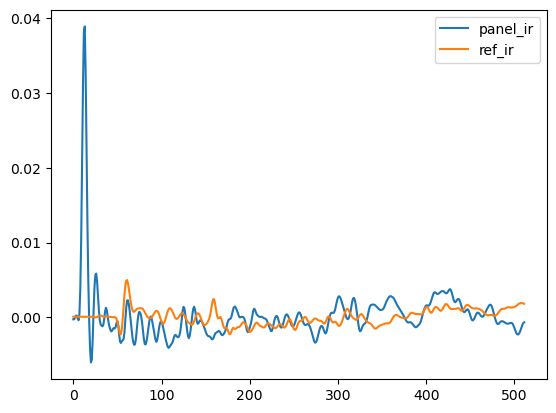

In [22]:
sharc.prep_irs(ir_len=512, panel_to_err_cm=4.5)

In [23]:
sharc.set_mu(0.003)
sharc.set_cancel_gain(0.09)
sharc.set_leak(1e-6)
sharc.set_lag(86)
sharc.reset()
sharc.cancel(20)
sharc.plot_error_mic()
sharc.plot_cumulative_error_reduction()

SystemError: MidiOutWinMM::sendMessage: error sending MIDI message.

In [27]:
test_params = [
    {"mu": 8e-4,  "cancel_gain": 0.055},
    {"mu": 9e-4,  "cancel_gain": 0.050},
    {"mu": 1.0e-3,"cancel_gain": 0.0475},
    {"mu": 1.1e-3,"cancel_gain": 0.045},
    {"mu": 1.2e-3,"cancel_gain": 0.0425},
    {"mu": 1.3e-3,"cancel_gain": 0.040},
    {"mu": 1.4e-3,"cancel_gain": 0.035},
    {"mu": 1.5e-3,"cancel_gain": 0.030},
    {"mu": 1.6e-3,"cancel_gain": 0.025},
]
for t in test_params:
    sharc.set_mu(t['mu'])
    sharc.set_cancel_gain(t['cancel_gain'])
    for _ in range(5):
        sharc.reset()
        print(t)
        sharc.cancel(2)
        print()

{'mu': 0.0008, 'cancel_gain': 0.055}
Overall ANC / No ANC: -1.22 dB

{'mu': 0.0008, 'cancel_gain': 0.055}
Overall ANC / No ANC: -1.18 dB

{'mu': 0.0008, 'cancel_gain': 0.055}
Overall ANC / No ANC: -1.13 dB

{'mu': 0.0008, 'cancel_gain': 0.055}
Overall ANC / No ANC: -1.22 dB

{'mu': 0.0008, 'cancel_gain': 0.055}
Overall ANC / No ANC: -1.21 dB

{'mu': 0.0009, 'cancel_gain': 0.05}
Overall ANC / No ANC: -1.21 dB

{'mu': 0.0009, 'cancel_gain': 0.05}
Overall ANC / No ANC: -1.21 dB

{'mu': 0.0009, 'cancel_gain': 0.05}
Overall ANC / No ANC: -1.25 dB

{'mu': 0.0009, 'cancel_gain': 0.05}
Overall ANC / No ANC: -1.11 dB

{'mu': 0.0009, 'cancel_gain': 0.05}
Overall ANC / No ANC: -1.16 dB

{'mu': 0.001, 'cancel_gain': 0.0475}
Overall ANC / No ANC: -1.27 dB

{'mu': 0.001, 'cancel_gain': 0.0475}
Overall ANC / No ANC: -1.14 dB

{'mu': 0.001, 'cancel_gain': 0.0475}
Overall ANC / No ANC: -1.23 dB

{'mu': 0.001, 'cancel_gain': 0.0475}
Overall ANC / No ANC: -1.22 dB

{'mu': 0.001, 'cancel_gain': 0.0475}
Ov

In [34]:
sharc.reset()
sharc.cancel(2)

Overall ANC / No ANC: -0.60 dB


np.float32(-0.6037656)

In [18]:
test_params = [
    {"mu": 0.0009, "cancel_gain": 0.050},
    {"mu": 0.0010, "cancel_gain": 0.0475},
    {"mu": 0.0011, "cancel_gain": 0.045},
    {"mu": 0.0012, "cancel_gain": 0.0425},
    {"mu": 0.0013, "cancel_gain": 0.040},
    {"mu": 0.0014, "cancel_gain": 0.035},
    {"mu": 0.0015, "cancel_gain": 0.030},
    {"mu": 0.0016, "cancel_gain": 0.025},
]

for t in test_params:
    sharc.set_mu(t['mu'])
    sharc.set_cancel_gain(t['cancel_gain'])
    sharc.reset()
    print(t)
    sharc.cancel(5)
    print()

{'mu': 0.0009, 'cancel_gain': 0.05}
Overall ANC / No ANC: -0.56 dB

{'mu': 0.001, 'cancel_gain': 0.0475}
Overall ANC / No ANC: -0.50 dB

{'mu': 0.0011, 'cancel_gain': 0.045}
Overall ANC / No ANC: -0.17 dB

{'mu': 0.0012, 'cancel_gain': 0.0425}
Overall ANC / No ANC: -0.12 dB

{'mu': 0.0013, 'cancel_gain': 0.04}
Overall ANC / No ANC: -0.30 dB

{'mu': 0.0014, 'cancel_gain': 0.035}
Overall ANC / No ANC: -0.19 dB

{'mu': 0.0015, 'cancel_gain': 0.03}
Overall ANC / No ANC: -0.47 dB

{'mu': 0.0016, 'cancel_gain': 0.025}
Overall ANC / No ANC: -0.73 dB



Overall ANC / No ANC: -1.01 dB


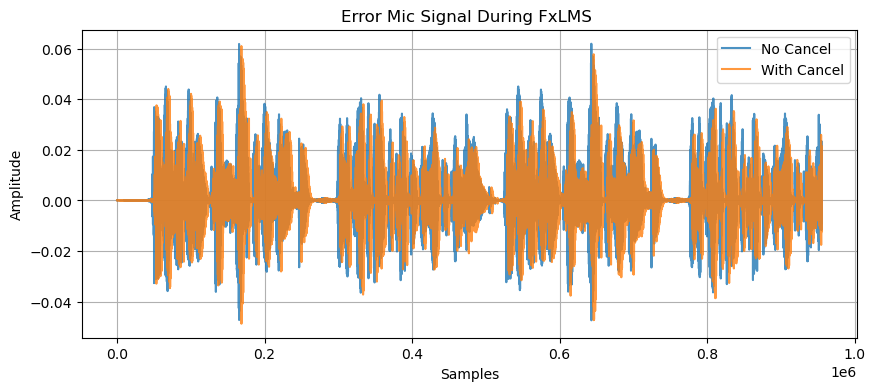

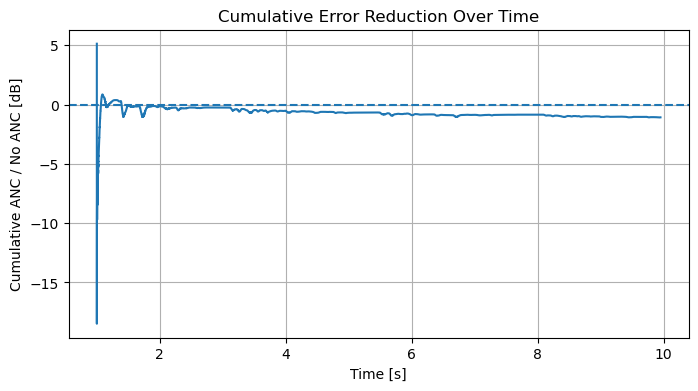

In [20]:
sharc.reset()
sharc.cancel(2)
sharc.plot_error_mic()
sharc.plot_cumulative_error_reduction()

Overall ANC / No ANC: -0.89 dB


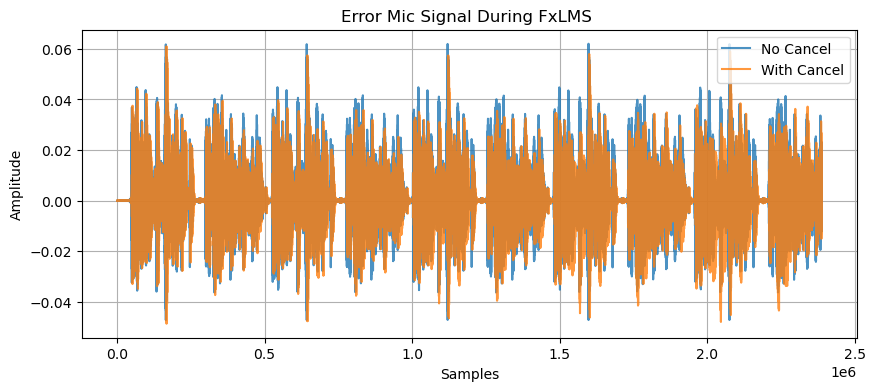

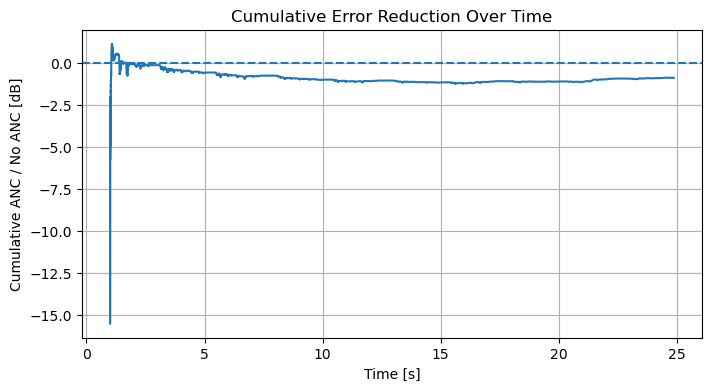

In [19]:
sharc.reset()
sharc.cancel(5)
sharc.plot_error_mic()
sharc.plot_cumulative_error_reduction()

In [37]:
test_params = [
    {"mu": 0.0009, "cancel_gain": 0.050},
    {"mu": 0.0010, "cancel_gain": 0.0475},
    {"mu": 0.0011, "cancel_gain": 0.045},
    {"mu": 0.0012, "cancel_gain": 0.0425},
    {"mu": 0.0013, "cancel_gain": 0.040},
    {"mu": 0.0014, "cancel_gain": 0.035},
    {"mu": 0.0015, "cancel_gain": 0.030},
    {"mu": 0.0016, "cancel_gain": 0.025},
]

for t in test_params:
    sharc.set_mu(t['mu'])
    sharc.set_cancel_gain(t['cancel_gain'])
    sharc.reset()
    print(t)
    sharc.cancel(2)
    print()

{'mu': 0.0009, 'cancel_gain': 0.05}
Overall ANC / No ANC: -0.41 dB

{'mu': 0.001, 'cancel_gain': 0.0475}
Overall ANC / No ANC: -0.48 dB

{'mu': 0.0011, 'cancel_gain': 0.045}


KeyboardInterrupt: 

In [ ]:
test_params = [
    {"mu": 7e-4,  "cancel_gain": 0.06},
    {"mu": 1e-3,  "cancel_gain": 0.05},
    {"mu": 1.3e-3,"cancel_gain": 0.025},
    {"mu": 1.6e-3,"cancel_gain": 0.025},
]

for t in test_params:
    sharc.set_mu(t['mu'])
    sharc.set_cancel_gain(t['cancel_gain'])
    for _ in range(5):
        sharc.reset()
        print(t)
        sharc.cancel(2)
        print()

{'mu': 0.0007, 'cancel_gain': 0.06}
Overall ANC / No ANC: 25.18 dB

{'mu': 0.0007, 'cancel_gain': 0.06}
Overall ANC / No ANC: -1.16 dB

{'mu': 0.0007, 'cancel_gain': 0.06}
Overall ANC / No ANC: -1.23 dB

{'mu': 0.0007, 'cancel_gain': 0.06}
Overall ANC / No ANC: -1.23 dB

{'mu': 0.0007, 'cancel_gain': 0.06}
Overall ANC / No ANC: 9.74 dB

{'mu': 0.001, 'cancel_gain': 0.05}
Overall ANC / No ANC: 4.22 dB

{'mu': 0.001, 'cancel_gain': 0.05}
Overall ANC / No ANC: -0.54 dB

{'mu': 0.001, 'cancel_gain': 0.05}
Overall ANC / No ANC: -1.08 dB

{'mu': 0.001, 'cancel_gain': 0.05}
Overall ANC / No ANC: -0.99 dB

{'mu': 0.001, 'cancel_gain': 0.05}
Overall ANC / No ANC: 12.95 dB

{'mu': 0.0013, 'cancel_gain': 0.025}
Overall ANC / No ANC: -1.18 dB

{'mu': 0.0013, 'cancel_gain': 0.025}
Overall ANC / No ANC: -1.19 dB

{'mu': 0.0013, 'cancel_gain': 0.025}
Overall ANC / No ANC: -1.16 dB

{'mu': 0.0013, 'cancel_gain': 0.025}
Overall ANC / No ANC: -0.31 dB

{'mu': 0.0013, 'cancel_gain': 0.025}
Overall ANC / 